Generating all summary graphs for NH...

2026 column data types: float64
2026 NaN count: 357


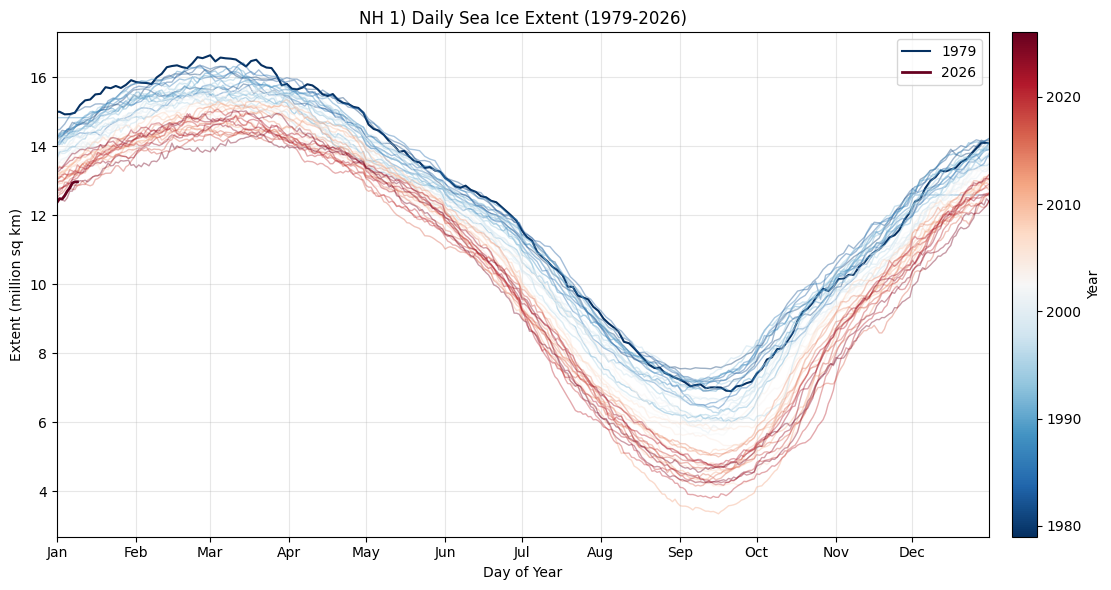

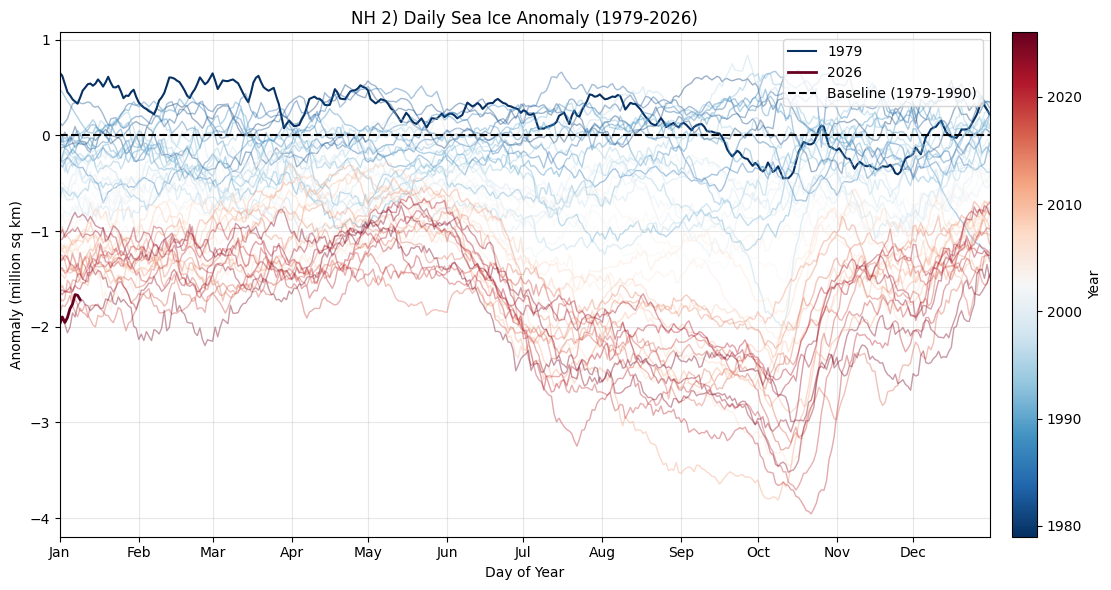

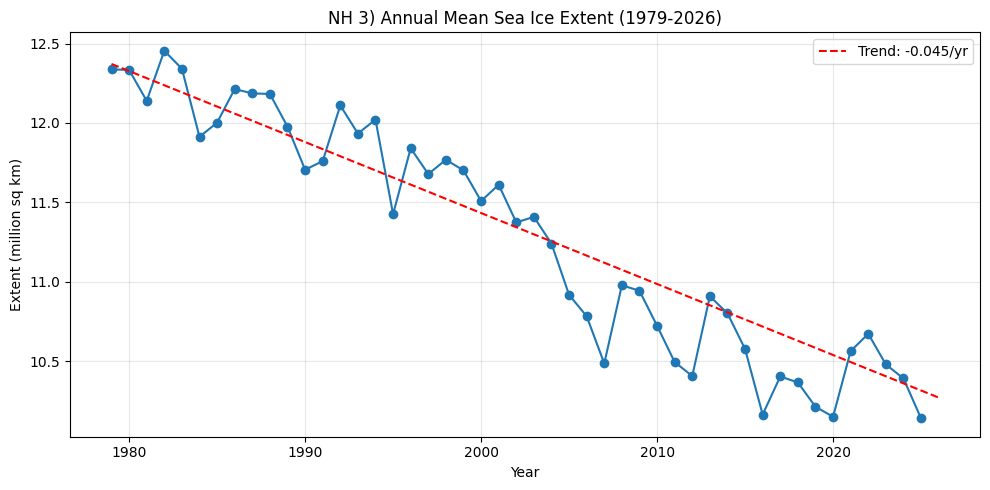

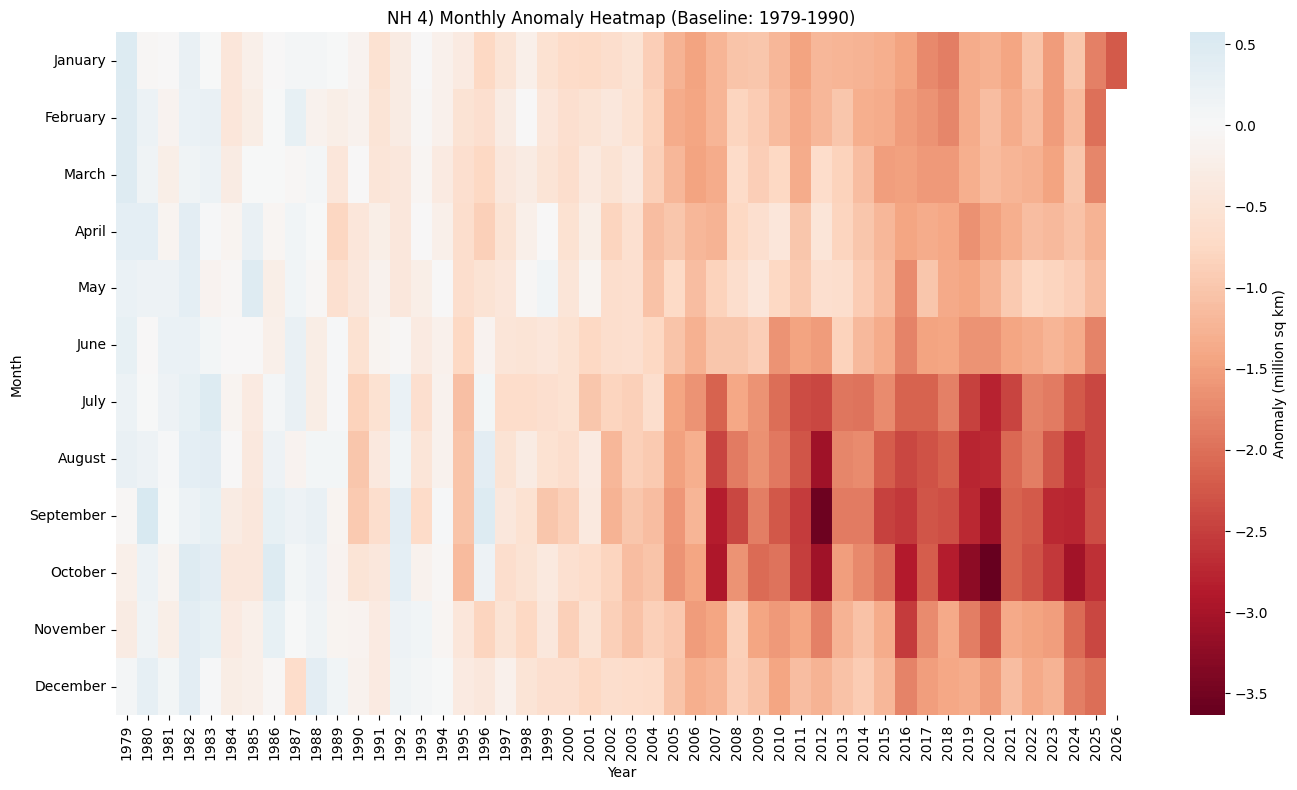

All graphs for NH saved successfully!
Valid data points in 2026: 9
Generating all summary graphs for SH...

2026 column data types: float64
2026 NaN count: 357


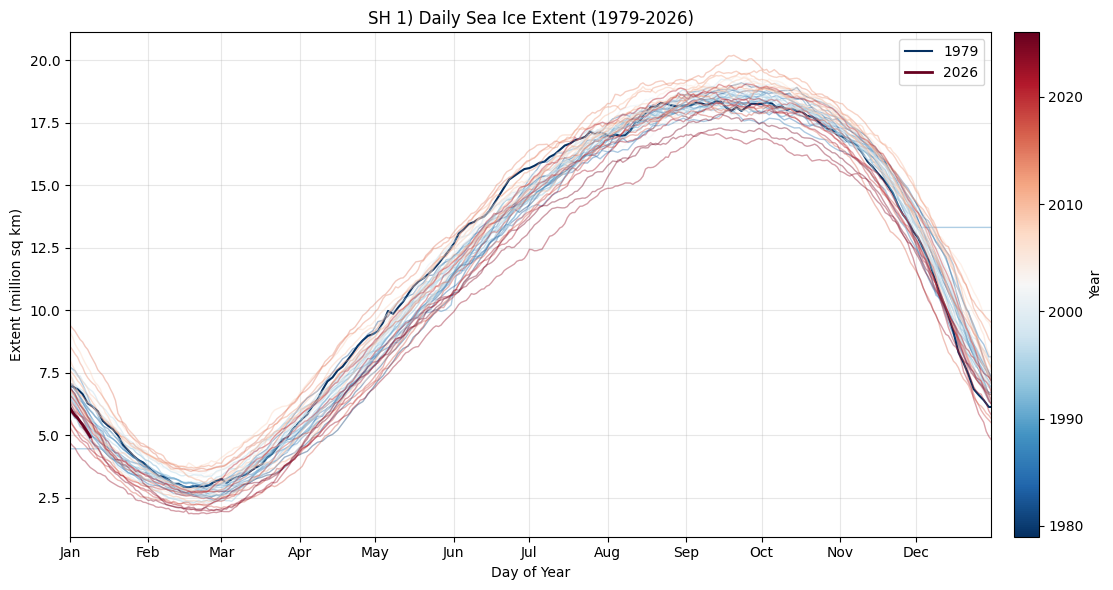

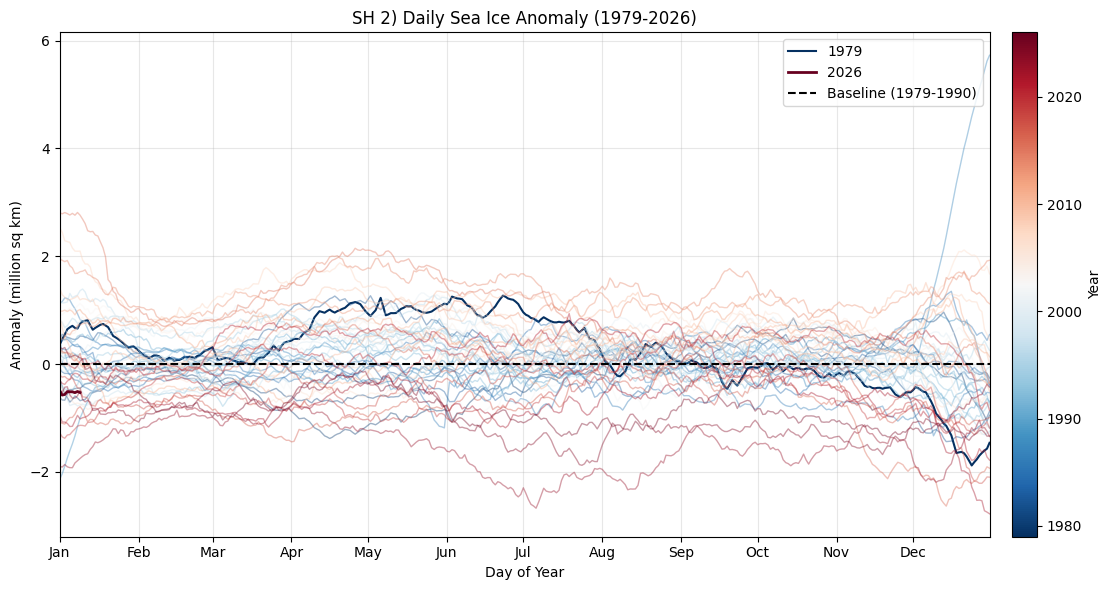

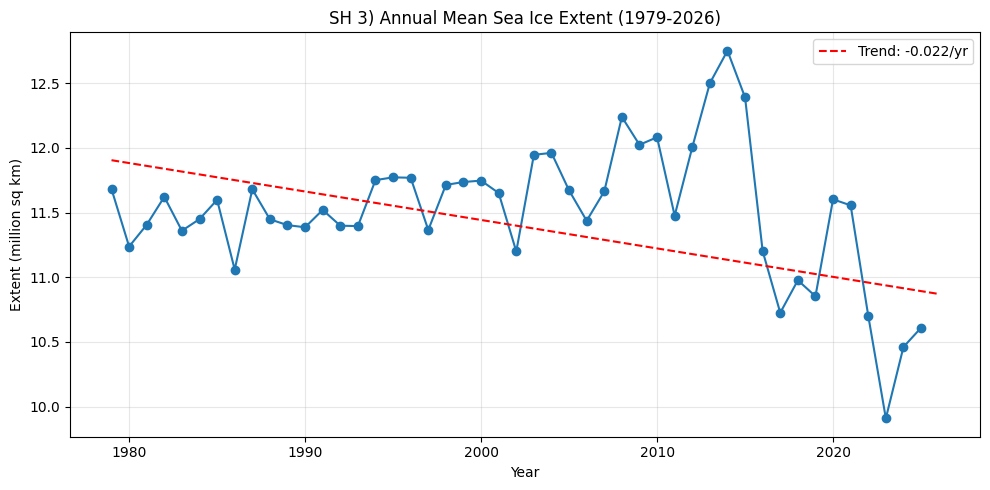

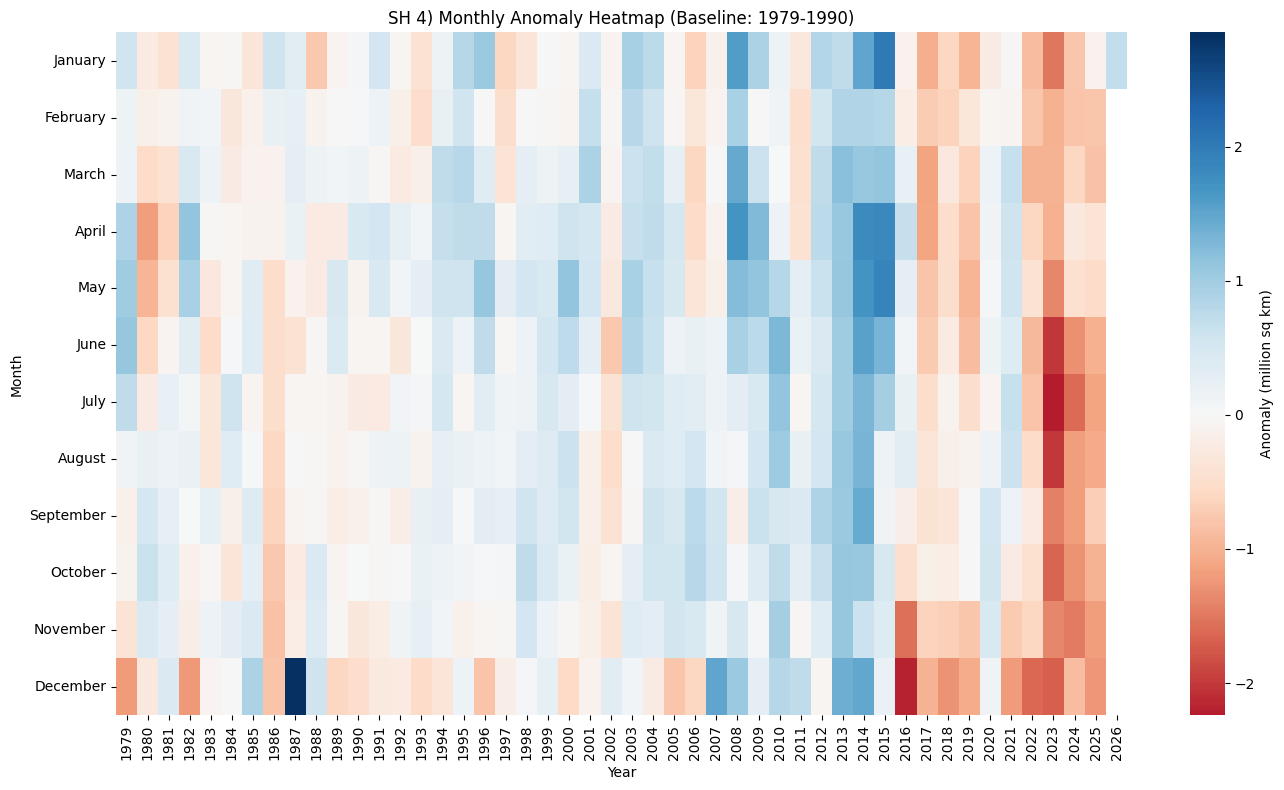

All graphs for SH saved successfully!
Valid data points in 2026: 9


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import calendar
from datetime import datetime

def generate_all_graphs(file_path, region_name):
    """
    指定された地域の海氷データから、以下の4つのグラフを作成・保存する関数
    1) 毎年の日毎の推移（グラデーション・凡例付き）
    2) 1979-1990年平均との偏差（グラデーション・凡例付き）
    3) 年ごとの平均値の推移
    4) 偏差のヒートマップ
    """
    print(f"Generating all summary graphs for {region_name}...")

    # --- データ読み込みと前処理 ---
    THIS_YEAR = 2026  # 2026年データに対応
    df = pd.read_csv(file_path)
    df.rename(columns={'Unnamed: 0': 'Month', 'Unnamed: 1': 'Day'}, inplace=True)
    df['Month'] = df['Month'].ffill()

    # 1979-2026年のデータを抽出
    years = [str(y) for y in range(1979, THIS_YEAR + 1)]
    cols = ['Month', 'Day'] + [y for y in years if y in df.columns]
    df = df[cols].copy()

    Month = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    Date = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

    #print("Original data:")
    #print(df)
    
    # 数値変換（NaN値はそのまま保持）
    for c in cols[2:]:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    
    # 2026年の1月以降がNaNの場合、それらを明示的にNaNとして保持
    # （平均値などが入っている場合は除外）
    print(f"\n2026 column data types: {df['2026'].dtype}")
    print(f"2026 NaN count: {df['2026'].isna().sum()}")
    
    # 線形補間は2025年までのデータのみに適用
    for c in cols[2:-1]:  # 2026年以外
        df[c] = df[c].interpolate(method='linear', limit_direction='both')
    
    # 2026年は補間せずNaNのまま保持（未来のデータは無視）
    # 必要に応じて: df['2026'] = df['2026']  # そのまま

    # --- 各種計算 ---
    # 基準値（1979-1990年平均）
    baseline_years = [str(y) for y in range(1979, 1991)]
    baseline_daily_mean = df[baseline_years].mean(axis=1)

    # 日別偏差（NaNは自動的に除外される）
    anomalies = df[cols[2:]].sub(baseline_daily_mean, axis=0)

    # 年平均値（NaNを除外して計算）
    annual_means = df[cols[2:]].mean(axis=0, skipna=True)

    # 月別偏差（ヒートマップ用）
    df_monthly = df.copy()
    monthly_means = df_monthly.groupby('Month')[cols[2:]].mean()
    # 月の並び順を修正
    month_order = list(calendar.month_name)[1:]
    monthly_means = monthly_means.reindex(month_order)
    # 月ごとの基準値と偏差
    monthly_baseline = monthly_means[baseline_years].mean(axis=1)
    monthly_anomalies = monthly_means.sub(monthly_baseline, axis=0)

    # --- グラフ描画設定（グラデーション用） ---
    cmap_name = 'RdBu_r'  # 青→赤
    cmap = plt.get_cmap(cmap_name)
    years_int = [int(y) for y in cols[2:]]
    norm = mcolors.Normalize(vmin=min(years_int), vmax=max(years_int))
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    plt.style.use('default')

    # グラフ1: 毎年の日毎の推移
    fig, ax = plt.subplots(figsize=(12, 6))
    for year in cols[2:]:
        y_int = int(year)
        color = cmap(norm(y_int))

        # 1979年と2026年のみ凡例用にラベルを設定
        if year == '1979':
            lw = 1.5
            alpha = 1.0
            label = '1979'
        elif year == '2026':
            lw = 2.0
            alpha = 1.0
            label = '2026'
        else:
            lw = 1
            alpha = 0.4
            label = None

        # NaN値を除外してプロット
        valid_data = df[year].dropna()
        valid_index = valid_data.index
        ax.plot(valid_index, valid_data, color=color, linewidth=lw, alpha=alpha, label=label)

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Year')
    ax.legend(loc='upper right')
    ax.set_title(f'{region_name} 1) Daily Sea Ice Extent (1979-2026)')
    ax.set_xticks(Date, Month)
    ax.set_ylabel('Extent (million sq km)')
    ax.set_xlabel('Day of Year')
    ax.set_xlim(0, 365)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{region_name}_1_daily_extent_2026.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # グラフ2: 基準値との偏差
    fig, ax = plt.subplots(figsize=(12, 6))
    for year in cols[2:]:
        y_int = int(year)
        color = cmap(norm(y_int))

        if year == '1979':
            lw = 1.5
            alpha = 1.0
            label = '1979'
        elif year == '2026':
            lw = 2.0
            alpha = 1.0
            label = '2026'
        else:
            lw = 1
            alpha = 0.4
            label = None

        # NaN値を除外してプロット
        valid_anomaly = anomalies[year].dropna()
        valid_index = valid_anomaly.index
        ax.plot(valid_index, valid_anomaly, color=color, linewidth=lw, alpha=alpha, label=label)

    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('Year')
    ax.axhline(0, color='black', linestyle='--', label='Baseline (1979-1990)')

    # 凡例の整理（重複回避）
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right')
    ax.set_title(f'{region_name} 2) Daily Sea Ice Anomaly (1979-2026)')
    ax.set_xticks(Date, Month)
    ax.set_ylabel('Anomaly (million sq km)')
    ax.set_xlabel('Day of Year')
    ax.set_xlim(0, 365)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{region_name}_2_daily_anomaly_2026.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # グラフ3: 年平均値の推移
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # NaNを除外した年平均値のみプロット
    valid_years = []
    valid_means = []
    for i, year in enumerate(years_int):
        mean_val = annual_means.iloc[i]
        if not pd.isna(mean_val):
            valid_years.append(year)
            valid_means.append(mean_val)
    
    ax.plot(valid_years[:-1], valid_means[:-1], marker='o', linestyle='-', color='tab:blue')
    
    # トレンドライン（有効なデータのみ使用）
    if len(valid_years) > 1:
        z = np.polyfit(valid_years, valid_means, 1)
        p = np.poly1d(z)
        ax.plot(valid_years, p(valid_years), "r--", label=f'Trend: {z[0]:.3f}/yr')

    ax.set_title(f'{region_name} 3) Annual Mean Sea Ice Extent (1979-2026)')
    ax.set_ylabel('Extent (million sq km)')
    ax.set_xlabel('Year')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{region_name}_3_annual_mean_2026.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # グラフ4: 偏差ヒートマップ
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.heatmap(monthly_anomalies, cmap='RdBu', center=0,
                cbar_kws={'label': 'Anomaly (million sq km)'}, 
                ax=ax, mask=monthly_anomalies.isna())  # NaN値をマスク
    ax.set_title(f'{region_name} 4) Monthly Anomaly Heatmap (Baseline: 1979-1990)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Month')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.savefig(f'{region_name}_4_heatmap_2026.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"All graphs for {region_name} saved successfully!")
    print(f"Valid data points in 2026: {df['2026'].notna().sum()}")

# NHとSHの処理を実行
generate_all_graphs('./気象データ/world/NH-Daily-Extent-表1.csv', 'NH')
generate_all_graphs('./気象データ/world/SH-Daily-Extent-表1.csv', 'SH')